<a href="https://colab.research.google.com/github/sanjanascorner/PyTorch-and-DeepLearning/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms
import numpy as np
import matplotlib.pyplot as plt


Loading the dataset

In [ ]:
normalize_transform= torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()])
train_dataset=torchvision.datasets.CIFAR10(
    root='./data/train',train=True,transform=normalize_transform,download=True)

test_dataset=torchvision.datasets.CIFAR10(
    root='./data/test',train=False,download=True,transform=normalize_transform)



100%|██████████| 170M/170M [29:13<00:00, 97.3kB/s]
100%|██████████| 170M/170M [26:13<00:00, 108kB/s] 


In [ ]:
print(train_dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Creating Data Loaders

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
batch_size=128
train_loader=DataLoader(train_dataset,batch_size=batch_size)
test_loader=DataLoader(test_dataset,batch_size=batch_size)



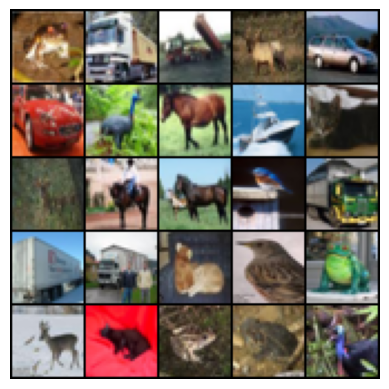

In [ ]:
dataiter=iter(train_loader)
images,labels=next(dataiter)
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], normalize=True, padding=1, nrow=5).numpy(), (1, 2, 0)))
plt.axis('off')
plt.show()


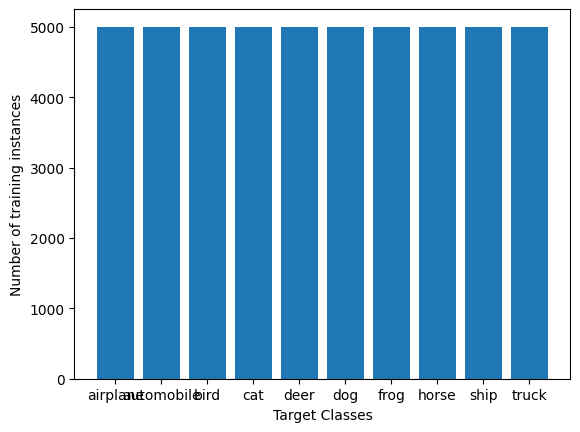

In [ ]:
classes = []
for batch_idx, data in enumerate(train_loader):
    x, y = data
    classes.extend(y.tolist())

unique, counts = np.unique(classes, return_counts=True)
names = list(test_dataset.class_to_idx.keys())
plt.bar(names, counts)
plt.xlabel("Target Classes")
plt.ylabel("Number of training instances")
plt.show()

In [ ]:
class CNN(nn.Module):
  def __init__(self):
      super().__init__()
      self.model=torch.nn.Sequential(
          torch.nn.Conv2d(in_channels=3,out_channels=16,
                          kernel_size=3,padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Conv2d(in_channels=16,out_channels=32,
                          kernel_size=3,padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Conv2d(in_channels=32,out_channels=32,
                          kernel_size=3,padding=1),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2),
          torch.nn.Flatten(),
          torch.nn.Linear(32*4*4,512),
          torch.nn.ReLU(),
          torch.nn.Linear(512,10)
      )
  def forward(self,x):
      return self.model(x)


In [ ]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN().to(device)
num_epochs = 100
learning_rate= 0.001
weight_decay=0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)





In [ ]:
train_loss_list=[]
for epoch in range(num_epochs):
  print(f'Epoch {epoch+1}/{num_epochs}:',end=" ")
  train_loss=0
  for images,labels in train_loader:
      images= images.to(device)
      labels=labels.to(device)
      outputs=model(images)
      loss=criterion(outputs,labels)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      train_loss += loss.item()
  train_loss_list.append(train_loss/len(train_loader))
  print(f"Training loss={train_loss_list[-1]}")


Epoch 1/100: Training loss=0.42985914674256465
Epoch 2/100: Training loss=0.40010577455505997
Epoch 3/100: Training loss=0.3767166055376877
Epoch 4/100: Training loss=0.35480522194786757
Epoch 5/100: Training loss=0.3437220080734214
Epoch 6/100: Training loss=0.33713824761188244
Epoch 7/100: Training loss=0.33168827816653434
Epoch 8/100: Training loss=0.3271538513090909
Epoch 9/100: Training loss=0.3232069045991239
Epoch 10/100: Training loss=0.31996062375090617
Epoch 11/100: Training loss=0.3163248724339868
Epoch 12/100: Training loss=0.3131924352377577
Epoch 13/100: Training loss=0.3101454095157516
Epoch 14/100: Training loss=0.30709727310463597
Epoch 15/100: Training loss=0.3040449972957601
Epoch 16/100: Training loss=0.3013378939665187
Epoch 17/100: Training loss=0.2983598480444125
Epoch 18/100: Training loss=0.2953893366981955
Epoch 19/100: Training loss=0.2926990391348329
Epoch 20/100: Training loss=0.28892002416693646
Epoch 21/100: Training loss=0.2864434950796844
Epoch 22/100: 

Plot of Training loss

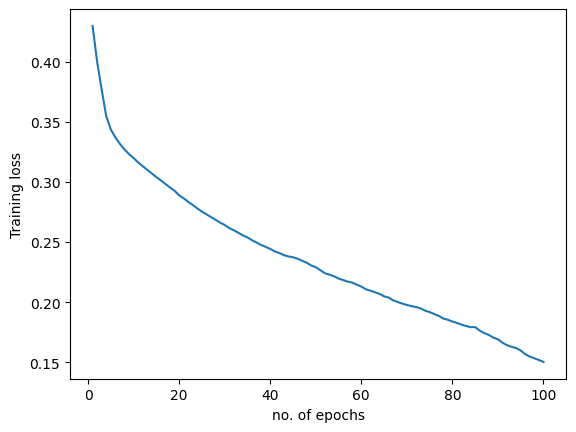

In [ ]:
plt.plot(range(1,num_epochs+1),train_loss_list)
plt.xlabel("no. of epochs")
plt.ylabel("Training loss")
plt.show()

In [ ]:
test_acc = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_true = labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()

print(f"Test set accuracy = {100 * test_acc / len(test_dataset)} %")

Test set accuracy = 70.62 %


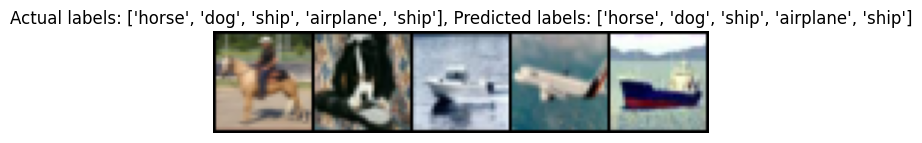

In [ ]:
num_images = 5
y_true_name = [names[y_true[idx]] for idx in range(num_images)]
y_pred_name = [names[y_pred[idx]] for idx in range(num_images)]
title = f"Actual labels: {y_true_name}, Predicted labels: {y_pred_name}"

plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:num_images].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
plt.title(title)
plt.axis("off")
plt.show()